In [2]:
import kagglehub
from pathlib import Path
import pandas as pd

path = kagglehub.dataset_download("erdemtaha/cancer-data")

print("Path to dataset files:", path)
path = Path(path)
csv_path = path / "cancer_data.csv" 

df = pd.read_csv(csv_path)

Path to dataset files: C:\Users\yana\.cache\kagglehub\datasets\erdemtaha\cancer-data\versions\1


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

label_encoder = LabelEncoder()
df['diagnosis'] = label_encoder.fit_transform(df['diagnosis'])

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Train: (398, 30)
Validation: (85, 30)
Test: (86, 30)


              precision    recall  f1-score   support

           B       0.87      1.00      0.93        53
           M       1.00      0.75      0.86        32

    accuracy                           0.91        85
   macro avg       0.93      0.88      0.89        85
weighted avg       0.92      0.91      0.90        85



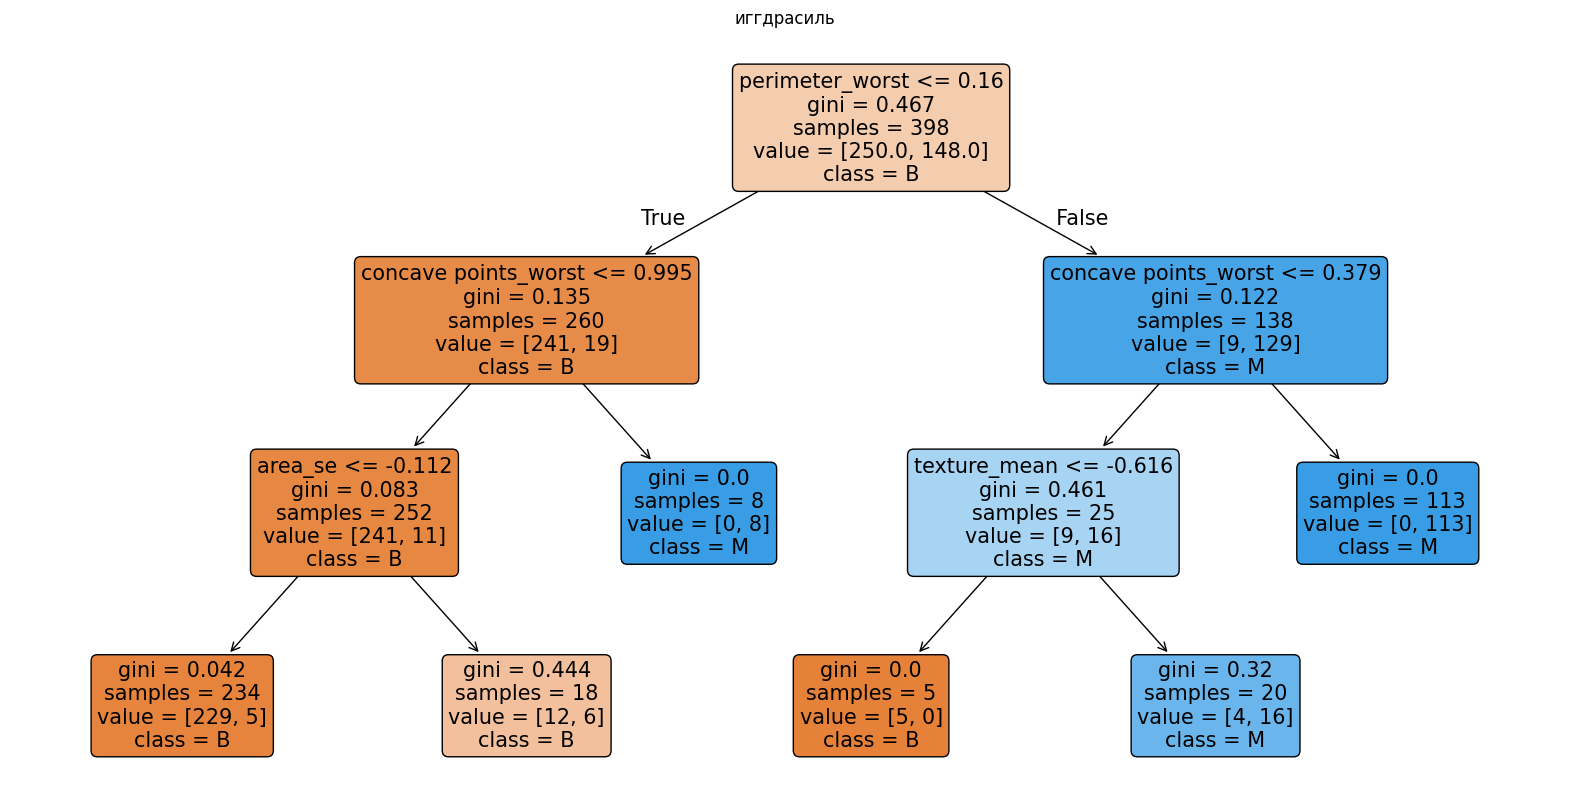

In [9]:
#дерево решений
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

clf = DecisionTreeClassifier(max_depth=3, random_state=42) #4<3
clf.fit(X_train_scaled, y_train)

y_val_pred = clf.predict(X_val_scaled)
print(classification_report(y_val, y_val_pred, target_names=['B', 'M']))

plt.figure(figsize=(20,10))
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['B', 'M'], 
          filled=True, 
          rounded=True)
plt.title("иггдрасиль")
plt.show()



In [10]:
#рандомфорест
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

forest = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
forest.fit(X_train_scaled, y_train)

y_val_pred = forest.predict(X_val_scaled)

print(classification_report(y_val, y_val_pred, target_names=['B', 'M']))


              precision    recall  f1-score   support

           B       0.95      1.00      0.97        53
           M       1.00      0.91      0.95        32

    accuracy                           0.96        85
   macro avg       0.97      0.95      0.96        85
weighted avg       0.97      0.96      0.96        85



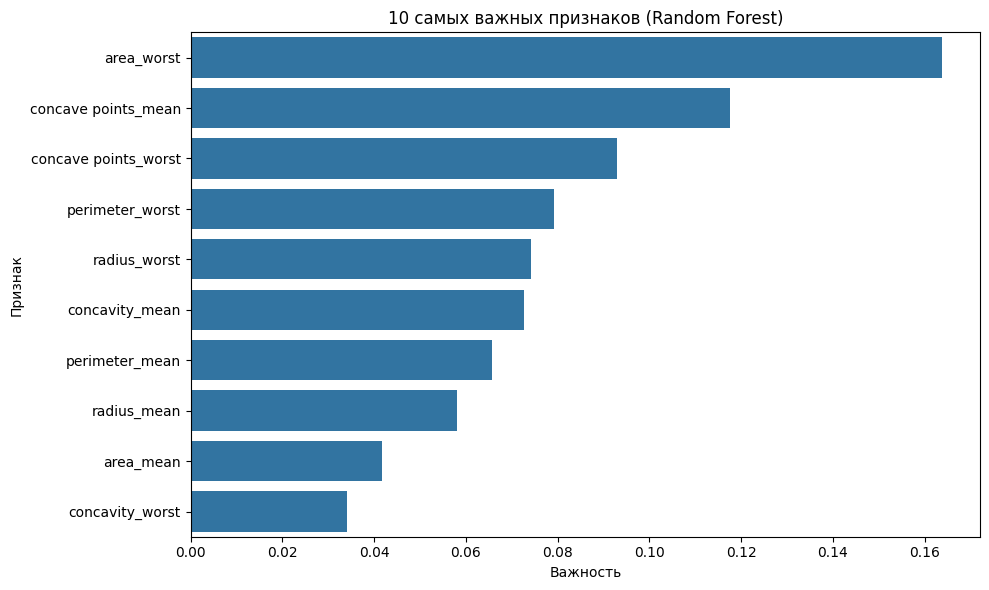

In [11]:
importances = forest.feature_importances_
features = X.columns
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10])
plt.title("10 самых важных признаков (Random Forest)")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           B       0.95      1.00      0.97        53
           M       1.00      0.91      0.95        32

    accuracy                           0.96        85
   macro avg       0.97      0.95      0.96        85
weighted avg       0.97      0.96      0.96        85



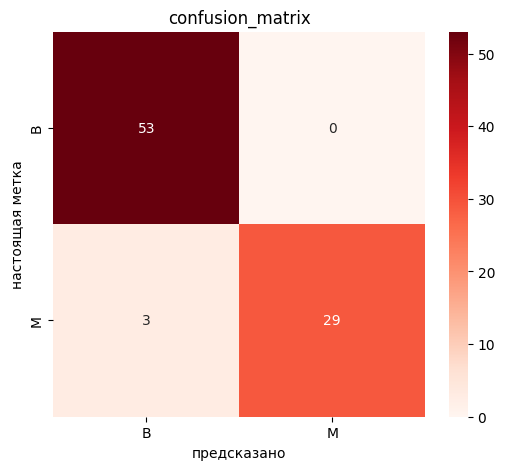

In [28]:
# логистическая регрессия
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

y_val_pred_lr = lr_model.predict(X_val_scaled)

#print("y_val:", len(y_val))
#print("y_val_pred_lr:", len(y_val_pred_lr))

print(classification_report(y_val, y_val_pred_lr, target_names=['B', 'M']))

cm_lr = confusion_matrix(y_val, y_val_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.xlabel("предсказано")
plt.ylabel("настоящая метка")
plt.title("confusion_matrix")
plt.show()


In [34]:
#для новых данных в логрег

new_sample = np.array([10.99, 10.38, 60.8, 1001.0, 0.1184,
                       0.9076, 0.3001, 0.1471, 0.2419, 0.07871,
                       0.095, 0.9053, 8.589, 13.4, 0.006399,
                       0.04904, 0.05373, 0.01587, 0.03003, 0.006193,
                       25.38, 17.33, 184.6, 2019.0, 0.1622,
                       0.6656, 0.799119, 0.2654, 0.2601, 0.1189])

new_df = pd.DataFrame([new_sample], columns=X.columns)

new_df_scaled = scaler.transform(new_df)

prediction = lr_model.predict(new_df_scaled)

predicted_label = label_encoder.inverse_transform(prediction)

print(f"Предсказанный диагноз: {predicted_label[0]}")
proba = lr_model.predict_proba(new_df_scaled)
print(f"Вероятность злокачественного (M): {proba[0][1]:.2%}")



Предсказанный диагноз: 0
Вероятность злокачественного (M): 39.35%


              precision    recall  f1-score   support

           B       0.98      0.98      0.98        53
           M       0.97      0.97      0.97        32

    accuracy                           0.98        85
   macro avg       0.97      0.97      0.97        85
weighted avg       0.98      0.98      0.98        85



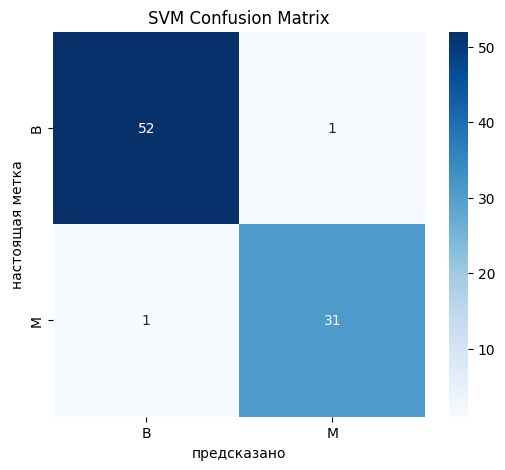

In [57]:
#svm
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_val_pred_svm = svm_model.predict(X_val_scaled)

print(classification_report(y_val, y_val_pred_svm, target_names=['B', 'M']))

cm = confusion_matrix(y_val, y_val_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['B', 'M'],
            yticklabels=['B', 'M'])
plt.xlabel('предсказано')
plt.ylabel('настоящая метка')
plt.title('SVM Confusion Matrix')
plt.show()


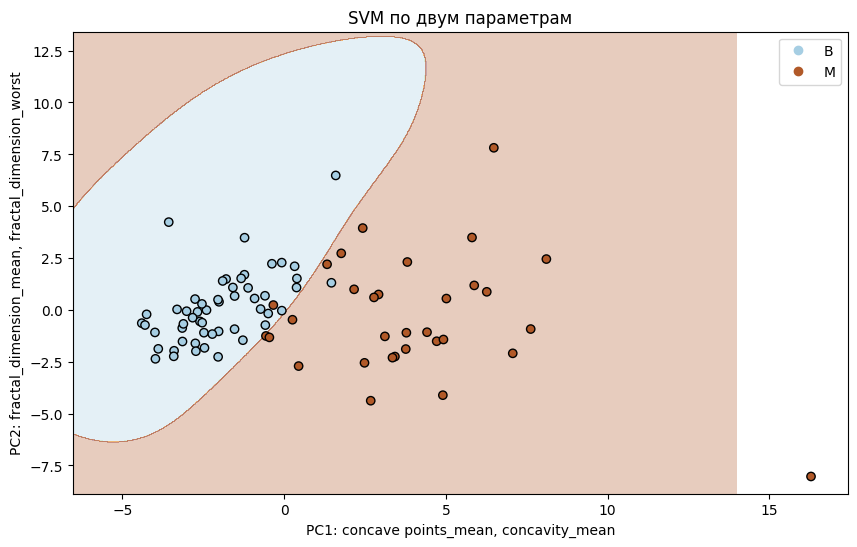

In [39]:
#визуализация по 2 pc
from sklearn.decomposition import PCA
from sklearn.svm import SVC

feature_names = X_train.columns.tolist()

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

svm_2d = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_2d.fit(X_train_pca, y_train)

def get_top_features_for_pcs(pca, feature_names, top_n=2):
    pc_labels = []
    for i, component in enumerate(pca.components_):
        top_indices = np.argsort(np.abs(component))[::-1][:top_n]
        top_feats = [feature_names[idx] for idx in top_indices]
        pc_labels.append(f"PC{i+1}: " + ", ".join(top_feats))
    return pc_labels

pc_labels = get_top_features_for_pcs(pca, feature_names)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
scatter = plt.scatter(X_val_pca[:, 0], X_val_pca[:, 1], c=y_val, 
                      cmap=plt.cm.Paired, edgecolors='k')

plt.xlabel(pc_labels[0])
plt.ylabel(pc_labels[1])
plt.title('SVM по двум параметрам')
plt.legend(handles=scatter.legend_elements()[0], labels=['B', 'M'])
plt.show()


In [55]:
#беггинг для дерева решений с ничтожной точностью
from sklearn.ensemble import BaggingClassifier

clf2 = DecisionTreeClassifier(max_depth=4, random_state=42)
bagging = BaggingClassifier(estimator=clf2, n_estimators=20, random_state=42)

bagging.fit(X_train_scaled, y_train)
y_val_pred = bagging.predict(X_val_scaled)

print(classification_report(y_val, y_val_pred, target_names=['B', 'M']))




              precision    recall  f1-score   support

           B       0.91      0.98      0.95        53
           M       0.96      0.84      0.90        32

    accuracy                           0.93        85
   macro avg       0.94      0.91      0.92        85
weighted avg       0.93      0.93      0.93        85



In [56]:
#грид серч гиперпараметров
from sklearn.model_selection import GridSearchCV

base_tree = DecisionTreeClassifier(random_state=42)

bagging = BaggingClassifier(estimator=base_tree, random_state=42)

param_grid = {
    'estimator__max_depth': [3, 4, 5, 6],
    'estimator__min_samples_split': [2, 5, 10],
    'n_estimators': [10, 20, 30],
    'max_samples': [0.8, 1.0],
    'max_features': [0.8, 1.0]
}

grid = GridSearchCV(
    bagging,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

y_val_pred = best_model.predict(X_val_scaled)

print("Лучшие параметры:", grid.best_params_)
print(classification_report(y_val, y_val_pred, target_names=['B', 'M']))


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Лучшие параметры: {'estimator__max_depth': 6, 'estimator__min_samples_split': 2, 'max_features': 0.8, 'max_samples': 0.8, 'n_estimators': 20}
              precision    recall  f1-score   support

           B       0.95      0.98      0.96        53
           M       0.97      0.91      0.94        32

    accuracy                           0.95        85
   macro avg       0.96      0.94      0.95        85
weighted avg       0.95      0.95      0.95        85

